# Comparison between Offline Methods

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle

list_df = []
for num in [50, 60, 70, 90, 120, 150]:
    scenario_name = f'ev_scenario-{num}'
    pickle_result = f'./offline/metrics_{scenario_name}'
    num = int(scenario_name.split('-')[1])
    dir_scenario = f'./offline/ev_scenario-{num}/'
    
    scenarios_results = []
    with open(f"{pickle_result}.pickle", "rb") as f:
        results = pickle.load(f)

    df_ = pd.DataFrame(columns=list(results[0].keys()))
    for i, res in enumerate(results):
        df_.loc[i] = list(res.values())
    df_['Algorithm'] = df_['filename'].apply(lambda x: x.split('-')[0].upper())
    df_['Scenarios'] = scenario_name
    list_df.append( df_ )

list_df = pd.concat( list_df )
list_df['timeout'] = list_df['timeout'].astype(float)
list_df['GAP_P1'] = list_df['GAP_P1'].astype(float)
list_df['GAP_P2'] = list_df['GAP_P2'].astype(float)
list_df['GAP_P3'] = list_df['GAP_P3'].astype(float)
list_df['reward value'] = list_df['reward value'].astype(float)
list_df['solved'] = list_df['solved'].astype(float)
TO_time = 1800

df_res = list_df.copy()
df_res['Timeout'] = df_res['computation_time'].apply(lambda e: 1. if e >= TO_time else 0.)
df_res['Computation Time'] = df_res['computation_time'].apply(lambda e: TO_time if e >= TO_time else e)
df_res['Scenarios'] = df_res['Scenarios'].replace({**{f'ev_scenario-{num}': f'Scenario {num} EVs' for num in [20, 30, 40, 50, 60, 70, 90, 120, 150]}})
df_res['num'] = df_res['filename'].apply(lambda e: e.split('-')[-1].split('.')[0])
df_res = df_res[['Scenarios', 'Algorithm', 'Computation Time', 'Timeout', 'GAP_P1', 'GAP_P2', 'GAP_P3', 'solved', 'reward value', 'num']]

df_res = df_res[(df_res['Algorithm'] == 'COMPLETE_MILP_GUROBI')]
df_res['Algorithm'] = df_res['Algorithm'].replace({'COMPLETE_MILP_GUROBI': 'MILP'})

default_values = {
    'Computation Time': 1800.0,  # Default computation time
    'Timeout': 1.0,              # Default timeout
    'GAP_P1': 0.,
    'GAP_P2': 0.,
    'GAP_P3': 0.,
    'solved': 0.,
}

expanded_df = pd.DataFrame()
for (scenario, algorithm), group in df_res.groupby(['Scenarios', 'Algorithm']):
    rows_to_add = 100 - len(group)
    if rows_to_add > 0:
        additional_rows = {key: [value] * rows_to_add for key, value in default_values.items()}
        additional_rows['Scenarios'] = [scenario] * rows_to_add
        additional_rows['Algorithm'] = [algorithm] * rows_to_add
        additional_df = pd.DataFrame(additional_rows)
        group = pd.concat([group, additional_df], ignore_index=True)
    expanded_df = pd.concat([expanded_df, group], ignore_index=True)

In [2]:
# Rename GAP_P1 to GAP for cleaner display
expanded_df_display = expanded_df.copy()
expanded_df_display['GAP'] = expanded_df_display['GAP_P1']

expanded_df_display.groupby(['Scenarios', 'Algorithm']).agg({
    'Computation Time': ['median', 'mean', 'std'],  # Get median, mean, and std for computation time
    'Timeout': ['sum'],
    'GAP': ['median', 'mean', 'std'],  # Get median, mean, and std for GAP
})

Computation Time                          Timeout  \
                                     median         mean         std     sum   
Scenarios        Algorithm                                                     
Scenario 120 EVs MILP                1800.0  1800.000000    0.000000   100.0   
Scenario 150 EVs MILP                1800.0  1800.000000    0.000000   100.0   
Scenario 50 EVs  MILP                1800.0  1572.677232  554.609599    85.0   
Scenario 60 EVs  MILP                1800.0  1754.419149  212.832490    94.0   
Scenario 70 EVs  MILP                1800.0  1800.000000    0.000000   100.0   
Scenario 90 EVs  MILP                1800.0  1800.000000    0.000000   100.0   

                                 GAP                      
                              median      mean       std  
Scenarios        Algorithm                                
Scenario 120 EVs MILP       0.270807  0.271771  0.076690  
Scenario 150 EVs MILP       0.346353  0.340857  0.100863  
Scenario 50 EVs  MILP       0.038261  0.045315  0.046488  
Scenario 60 EVs  MILP       0.065627  0.067807  0.045582  
Scenario 70 EVs  MILP       0.135755  0.131305  0.061927  
Scenario 90 EVs  MILP       0.185120  0.193509  0.062848

# General Comparative Results

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def global_cost_distribution_perc_on_lb_corrected(data, selected_scenarios, bar_width=.6, 
                                                 space_between_groups=.1, figsize=(20, 10), 
                                                 scenario_pad=70):
    def manually_parse_rewards(reward_string):
        try:
            rewards = reward_string.strip('[]').split()
            return [float(reward) for reward in rewards]
        except:
            return []

    data['Parsed Detailed Rewards'] = data['Detailed obj. cost'].apply(manually_parse_rewards)
    
    # Create expanded data with instance identifiers
    expanded_data = pd.DataFrame(columns=['Scenario', 'Algorithm', 'Reward', 'Instance'])
    for index, row in data.iterrows():
        for i, reward in enumerate(row['Parsed Detailed Rewards']):
            expanded_data = expanded_data.append({
                'Scenario': row['Scenario'],
                'Algorithm': row['Algorithm'],
                'Reward': reward,
                'Instance': i  # Add instance identifier
            }, ignore_index=True)
    
    unique_algorithms = ['MILP', 'Baseline', 'PS2C', 'MPPO', 'Rolling']
    colors = ['#006400', '#008B8B', '#8B0000', '#00008B', '#9400D3', '#FF8C00', '#A9A9A9', '#808080']
    color_map = dict(zip(unique_algorithms, colors))
    fig, ax = plt.subplots(figsize=figsize)
    group_width = len(unique_algorithms) * bar_width + (len(unique_algorithms) - 1) * bar_width
    
    bar_positions = []
    scenario_positions = [i * (group_width + space_between_groups) + group_width / 3.01 for i in range(len(selected_scenarios))]
    algorithm_labels = []
    
    for i, scenario in enumerate(selected_scenarios):
        scenario_position = i * (group_width + space_between_groups)
        
        # Get MILP (optimal) rewards for this scenario
        milp_data = expanded_data[(expanded_data['Scenario'] == scenario) & 
                                 (expanded_data['Algorithm'] == 'MILP')]
        milp_gaps = df_res[(df_res['Scenarios'] == scenario) & 
                          (df_res['Algorithm'] == 'MILP')]['GAP_P1']
        
        # Compute optimal values per instance
        optimal_values_per_instance = {}
        for idx, (_, row) in enumerate(milp_data.iterrows()):
            instance = row['Instance']
            reward = row['Reward']
            gap = milp_gaps.iloc[idx] if idx < len(milp_gaps) else 0
            optimal_values_per_instance[instance] = reward * (1 + gap)
        
        print(optimal_values_per_instance)
        for j, algorithm in enumerate(unique_algorithms):
            algorithm_position = scenario_position + j * bar_width
            bar_positions.append(algorithm_position)
            
            # Get algorithm data for this scenario
            alg_data = expanded_data[(expanded_data['Scenario'] == scenario) & 
                                   (expanded_data['Algorithm'] == algorithm)]
            
            if not alg_data.empty:
                # Compute percentage relative to optimal for each instance
                relative_rewards = []
                for _, row in alg_data.iterrows():
                    instance = row['Instance']
                    reward = row['Reward']
                    if instance in optimal_values_per_instance:
                        optimal_val = optimal_values_per_instance[instance]
                        if optimal_val > 0:  # Avoid division by zero
                            relative_rewards.append((reward / optimal_val) * 100)
                
                if relative_rewards:  # Only plot if we have data
                    parts = ax.violinplot(relative_rewards, positions=[algorithm_position], 
                                        showextrema=False, showmedians=True)
                    # Apply styling as before
                    for pc in parts['bodies']:
                        pc.set_facecolor('none')
                        pc.set_edgecolor(colors[j])
                        pc.set_linewidth(3.0)
                        pc.set_alpha(0.4)
                    parts['cmedians'].set_edgecolor(colors[j])
                    parts['cmedians'].set_alpha(0.5)
                    parts['cmedians'].set_linewidth(1.5)
            
            algorithm_labels.append(algorithm)
    
    # Rest of the plotting code remains the same...
    ax.set_xticks(scenario_positions)
    ax.set_xticklabels(selected_scenarios, verticalalignment='top', 
                      horizontalalignment='right', weight='bold', fontsize=13)
    ax.set_xticks(bar_positions, minor=True)
    ax.set_xticklabels(algorithm_labels, minor=True, rotation=30, 
                      verticalalignment='top', horizontalalignment='right', fontsize=12)
    ax.tick_params(axis='x', which='major', pad=scenario_pad, rotation=0, length=0)
    ax.set_xlabel('Scenarios and Algorithms', fontsize=16, labelpad=20)
    ax.set_ylabel('Relative Reward to Instance-Specific Optimal (in %)', fontsize=16)
    ax.grid(True, linestyle='-', linewidth=.5, axis='y')
    plt.savefig('dist_obj_perc_on_ub_corrected.png', dpi=600, bbox_inches='tight')
    plt.show()

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def global_cost_distribution_perc_on_lb(data, selected_scenarios, bar_width=.6, space_between_groups=.1,
                                        figsize=(20, 10), scenario_pad=70):
    def manually_parse_rewards(reward_string):
        try:
            rewards = reward_string.strip('[]').split()
            return [float(reward) for reward in rewards]
        except:
            return []

    data['Parsed Detailed Rewards'] = data['Detailed obj. cost'].apply(manually_parse_rewards)
    expanded_data = pd.DataFrame(columns=['Scenario', 'Algorithm', 'Cost'])
    for index, row in data.iterrows():
        for reward in row['Parsed Detailed Rewards']:
            expanded_data = expanded_data.append({
                'Scenario': row['Scenario'],
                'Algorithm': row['Algorithm'],
                'Reward': reward
            }, ignore_index=True)
    
    unique_algorithms = ['MILP', 'Baseline', 'PS2C', 'MPPO', 'Rolling']
    colors = ['#006400', '#008B8B', '#8B0000', '#00008B', '#9400D3', '#FF8C00', '#A9A9A9', '#808080']
    color_map = dict(zip(unique_algorithms, colors))
    fig, ax = plt.subplots(figsize=figsize)
    group_width = len(unique_algorithms) * bar_width + (len(unique_algorithms) - 1) * bar_width
    
    bar_positions = []
    scenario_positions = [i * (group_width + space_between_groups) + group_width / 3.01 for i in range(len(selected_scenarios))]
    algorithm_labels = []
    optimal_value = []
    optimal_value_no_wg = []
    
    for i, scenario in enumerate(selected_scenarios):
        algorithm = 'MILP'
        rewards = expanded_data[(expanded_data['Scenario'] == scenario) & (expanded_data['Algorithm'] == algorithm)]['Reward']
        gaps = df_res[(df_res['Scenarios'] == scenario) & (df_res['Algorithm'] == algorithm)]['GAP_P1']
        assert len(gaps) == len(rewards)
        opt_rewards = rewards.to_numpy() * ( 1 + gaps.to_numpy() )
        optimal_value.append( np.median(opt_rewards) )
        
    for i, scenario in enumerate(selected_scenarios):
        scenario_position = i * (group_width + space_between_groups)
        for j, algorithm in enumerate(unique_algorithms):
            algorithm_position = scenario_position + j * bar_width
            bar_positions.append(algorithm_position)
            rewards = expanded_data[(expanded_data['Scenario'] == scenario) & (expanded_data['Algorithm'] == algorithm)]['Reward']
            if not rewards.empty:
                parts = ax.violinplot(rewards / optimal_value[i] * 100, positions=[algorithm_position], showextrema=False, showmedians=True)
                # Remove fill color and set border style
                for i, pc in enumerate(parts['bodies']):
                    pc.set_facecolor('none')  # Remove fill color
                    pc.set_edgecolor(colors[j])  # Set edge color to black
                    pc.set_linewidth(3.0)  # Set larger border
                    pc.set_alpha(0.4)
                parts['cmedians'].set_edgecolor(colors[j])
                parts['cmedians'].set_alpha(0.5)
                parts['cmedians'].set_linewidth(1.5)
            algorithm_labels.append(algorithm)
    
    ax.set_xticks(scenario_positions)
    ax.set_xticklabels(selected_scenarios, verticalalignment='top', horizontalalignment='right', weight='bold', fontsize=13)
    ax.set_xticks(bar_positions, minor=True)
    ax.set_xticklabels(algorithm_labels, minor=True, rotation=30, verticalalignment='top', horizontalalignment='right', fontsize=12)
    ax.tick_params(axis='x', which='major', pad=scenario_pad, rotation=0, length=0)  # Add space between major ticks (scenarios) and their labels
    ax.set_xlabel('Scenarios and Algorithms', fontsize=16, labelpad=20)
    ax.set_ylabel('Relative Reward to Median Upper Bound (in %)', fontsize=16)
    ax.grid(True, linestyle='-', linewidth=.5, axis='y')
    plt.savefig('dist_obj_perc_on_ub.png', dpi=600, bbox_inches='tight')
    plt.show()


In [5]:
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999
directory_with_name_list = [('offline', 'offline'),
                            ('rule_based', 'rbc'),
                            ('rolling', 'rolling'),
                            ('reinforcement_learning', 'CustomMPPO')]
columns_selected = ['Algorithm', 'Obj. cost', 'Charging satisf. <80%', 'Charging satisf. >=80%', 'Overall charging satisf.', 'Price', 'Total Energy', 'RES used', 'Energy/EV', 'scenario_name']
scenario_name_dic = {
    50:  'scenario-50',
    60:  'scenario-60',
    70:  'scenario-70',
    90:  'scenario-90',
    120: 'scenario-120',
    150: 'scenario-150',
}

list_df = []
for (dir_name, method_name) in directory_with_name_list:
    for scn_num in scenario_name_dic:
        list_df.append( pd.read_csv(f"./{dir_name}/analysis_{method_name}_{scn_num}.csv",
                                    sep='\t') )
        if(method_name == 'CustomMPPO'):
            list_df[-1] = list_df[-1].loc[(list_df[-1]['Algorithm'] == 'MPPO_eval')]
        
        list_df[-1]['Scenario'] = scenario_name_dic[scn_num]
        list_df[-1]['Scenario'] = list_df[-1]['Scenario'].replace({**{f'scenario-{num}': f'Scenario {num} EVs' for num in [50, 60, 70, 90, 120, 150]}})
        list_df[-1]['Algorithm'] = list_df[-1]['Algorithm'].replace({'COMPLETE_MODEL': 'MILP', 'BASELINE': 'Baseline', 'PS2C': 'PS2C', 'MPPO_eval': 'MPPO', 'ROLLING': 'Rolling'})
        list_df[-1] = list_df[-1][(list_df[-1]['Algorithm'] == 'MILP') | (list_df[-1]['Algorithm'] == 'Baseline') | (list_df[-1]['Algorithm'] == 'PS2C') | (list_df[-1]['Algorithm'] == 'MPPO') | (list_df[-1]['Algorithm'] == 'Rolling')]

df = pd.concat( list_df )
df.sort_values(by=['Scenario', 'Algorithm'])

,Algorithm,Charging satisf. <80%,Charging satisf. >=80%,Overall charging satisf.,Overall charging unsatisf.,Charging auto rejection,Price,Grid limit,Total Energy,Total PV,PV used,Grid used,PV used/Total PV,PV used/Total Energy,Energy/EV,SoC charged,Final SoC,Waiting Time,Obj. cost,Detailed obj. cost,Detailed PV used,Detailed Total Energy,Detailed Total PV,Scenario
3,Baseline,25.99±4.21%,29.41±4.43%,55.40±3.57%,44.60±3.57%,23.03±3.82%,82.71±16.28,0,1272.80±91.72,287.29±129.06,282.46±126.01,990.34±112.62,98.64±3.25%,21.94±9.50%,19.17±1.14,38.77±2.31%,79.00±2.81%,33.96±3.59,4111.09±549.75,[4751.21780823 4079.07372816 4489.48020186 468...,[420.18064692 379.37426393 456.81539136 440.85...,[1408.00256467 1188.63698228 1362.01337273 137...,[422.46783495 428.5436623 456.90091747 440.85...,Scenario 120 EVs
0,MILP,9.87±3.27%,51.60±4.39%,61.47±3.48%,38.53±3.48%,0.00±0.00%,61.61±17.38,0,1054.93±77.18,287.29±129.06,284.25±126.94,770.68±149.51,99.19±2.31%,27.13±12.34%,14.31±0.81,28.94±1.64%,73.54±2.36%,29.02±2.74,6867.99±548.90,[7076.47178349 6974.20551548 7360.04937443 740...,[422.46783495 382.10515478 456.04374434 440.52...,[1157.75 1040.05 1155.55 1123.65 982.85 1097....,[422.46783495 428.5436623 456.90091747 440.85...,Scenario 120 EVs
0,MPPO,8.12±2.75%,38.51±3.24%,46.62±3.23%,53.37±3.23%,0.68±1.34%,77.80±15.47,0,1228.37±73.01,287.29±129.06,282.84±125.68,945.53±120.27,98.82±1.83%,22.89±10.05%,22.00±1.23,44.50±2.49%,89.58±1.81%,12.06±1.83,5102.70±411.95,[5559.53520062 4890.30440862 5313.72987393 509...,[417.09524981 388.96286374 450.18357428 430.66...,[1321.74324358 1185.91877756 1312.88483502 129...,[422.46783495 428.5436623 456.90091747 440.85...,Scenario 120 EVs
0,PS2C,19.23±3.23%,36.16±3.68%,55.39±3.57%,44.61±3.57%,23.02±3.82%,70.37±15.69,0,1144.62±61.43,287.29±129.06,279.59±124.25,865.02±121.13,97.77±2.09%,24.32±10.72%,17.26±0.93,34.89±1.88%,75.13±1.74%,33.97±3.59,4933.33±467.26,[5571.59118502 4585.80712572 5202.40484302 510...,[415.7471805 388.56559932 437.93252732 438.26...,[1199.83533031 1130.49434208 1213.88409708 119...,[422.46783495 428.5436623 456.90091747 440.85...,Scenario 120 EVs
0,Rolling,18.21±3.01%,35.75±3.37%,53.96±3.91%,46.04±3.91%,34.53±4.46%,51.64±13.97,0,898.05±63.50,287.29±129.06,268.30±117.52,629.76±120.52,94.47±5.52%,29.82±12.98%,13.91±1.12,28.14±2.26%,67.34±2.42%,38.78±3.97,4885.86±433.29,[5566.5595919 4394.09020342 5215.84246963 522...,[402.89591902 329.05203422 447.32469633 424.06...,[1037.3 788.15 988.9 981.75 845.35 859....,[422.46783495 428.5436623 456.90091747 440.85...,Scenario 120 EVs
3,Baseline,21.32±3.04%,24.01±3.37%,45.33±3.32%,54.67±3.32%,29.00±3.42%,85.62±14.64,0,1300.73±93.35,287.09±124.27,285.32±123.05,1015.42±112.56,99.47±1.54%,21.72±9.08%,19.16±1.08,38.76±2.18%,78.64±2.08%,35.75±2.75,4195.28±534.22,[4470.34530659 4279.26507149 4282.62307314 485...,[396.73377146 329.54039833 64.39055352 386.71...,[1325.18737124 1336.8896834 1238.15982214 147...,[400.70933723 329.58364312 64.39055352 386.71...,Scenario 150 EVs
0,MILP,9.56±2.93%,42.37±4.00%,51.93±2.96%,48.07±2.96%,0.00±0.00%,61.56±17.43,0,1052.97±85.84,287.09±124.27,286.00±123.42,766.98±158.30,99.68±0.91%,27.48±12.27%,13.52±0.86,27.34±1.74%,72.86±2.20%,28.47±1.87,7073.44±622.64,[5913.89784862 6839.3910089 7587.42905535 745...,[398.19841875 329.56008904 64.39055352 386.06...,[ 897.05 1035.65 1090.1 1107.15 1128.05 1089....,[400.70933723 329.58364312 64.39055352 386.71...,Scenario 150 EVs
0,MPPO,7.96±2.13%,31.94±2.65%,39.90±2.51%,60.10±2.51%,1.26±1.46%,81.87±14.77,0,1272.75±76.53,287.09±124.27,284.67±122.47,988.08±110.92,99.32±0.96%,22.18±9.33%,21.29±0.94,43.05±1.90%,88.46±1.64%,13.57±1.78,5307.63±419.45,[4864.66894513 5299.50466784 5284.18794694 595...,[396.39613039 326.92263985 64.39055352 382.93...,[1200.46993653 1331.8759615 1222.5110841 135...,[400.70933723 329.58364312 64.39055352 386.71...,Scenario 150 EVs
0,PS2C,15.85±2.35%,29.48±3.22%,45.33±3.32%,54.67±3.32%,29.00±3.42%,72.40±14.93,0,1167.22±61.73,287.09±124.27,280.54±120.08,886.68±119.80,98

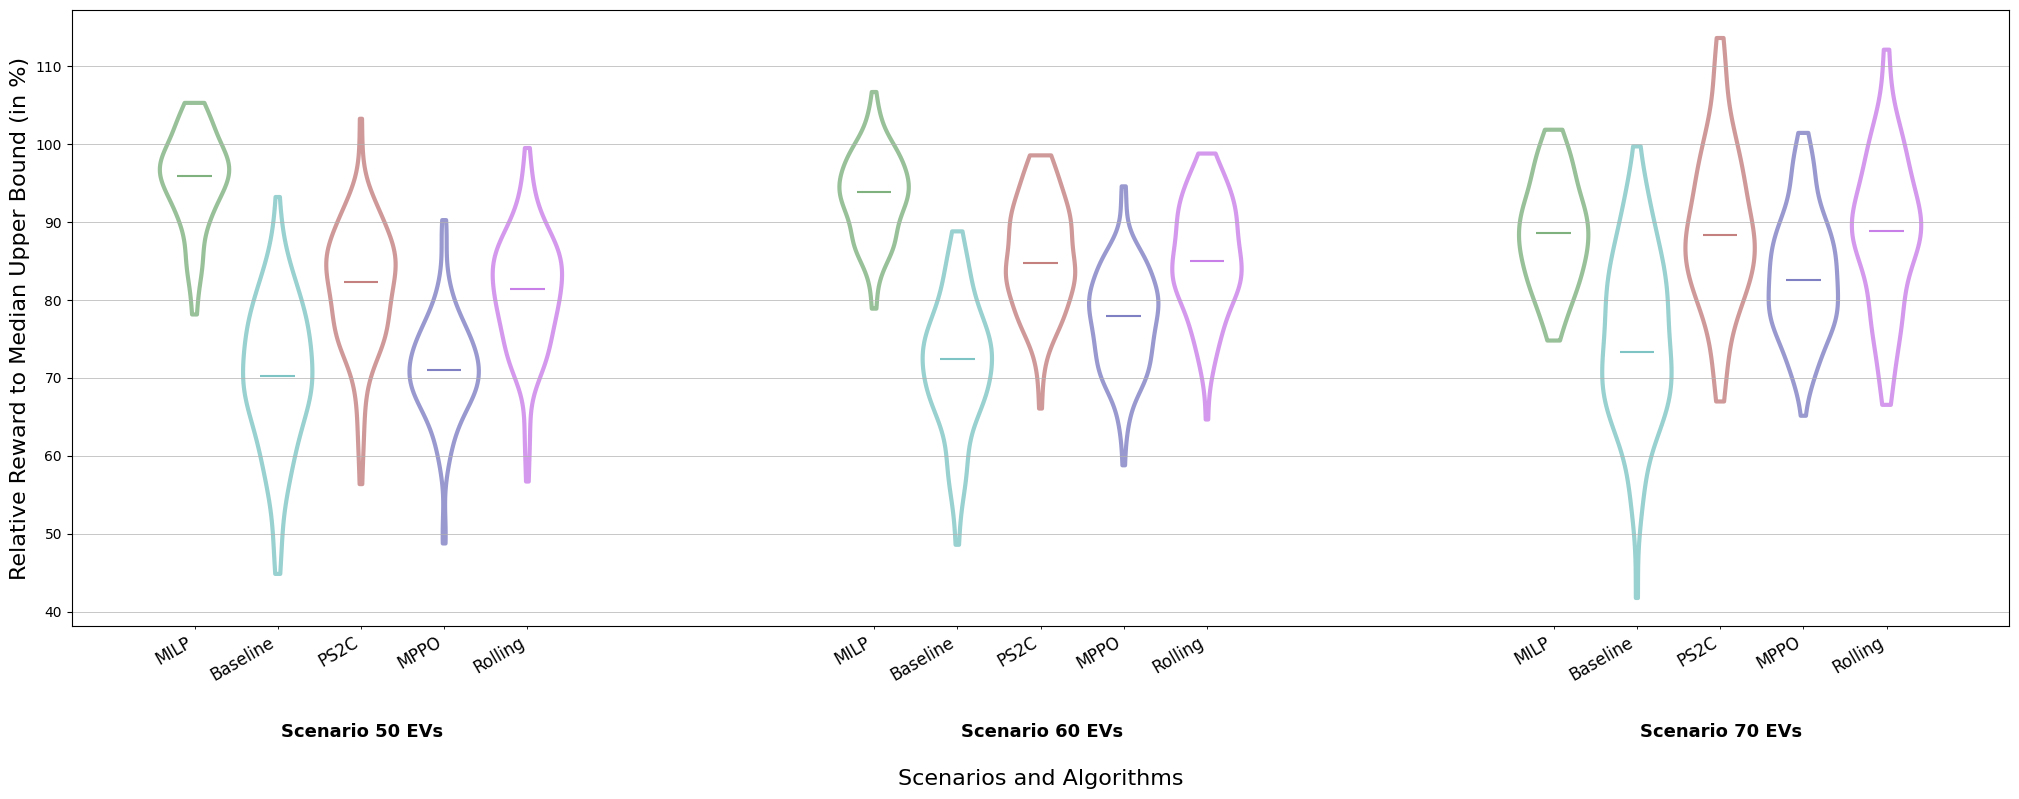

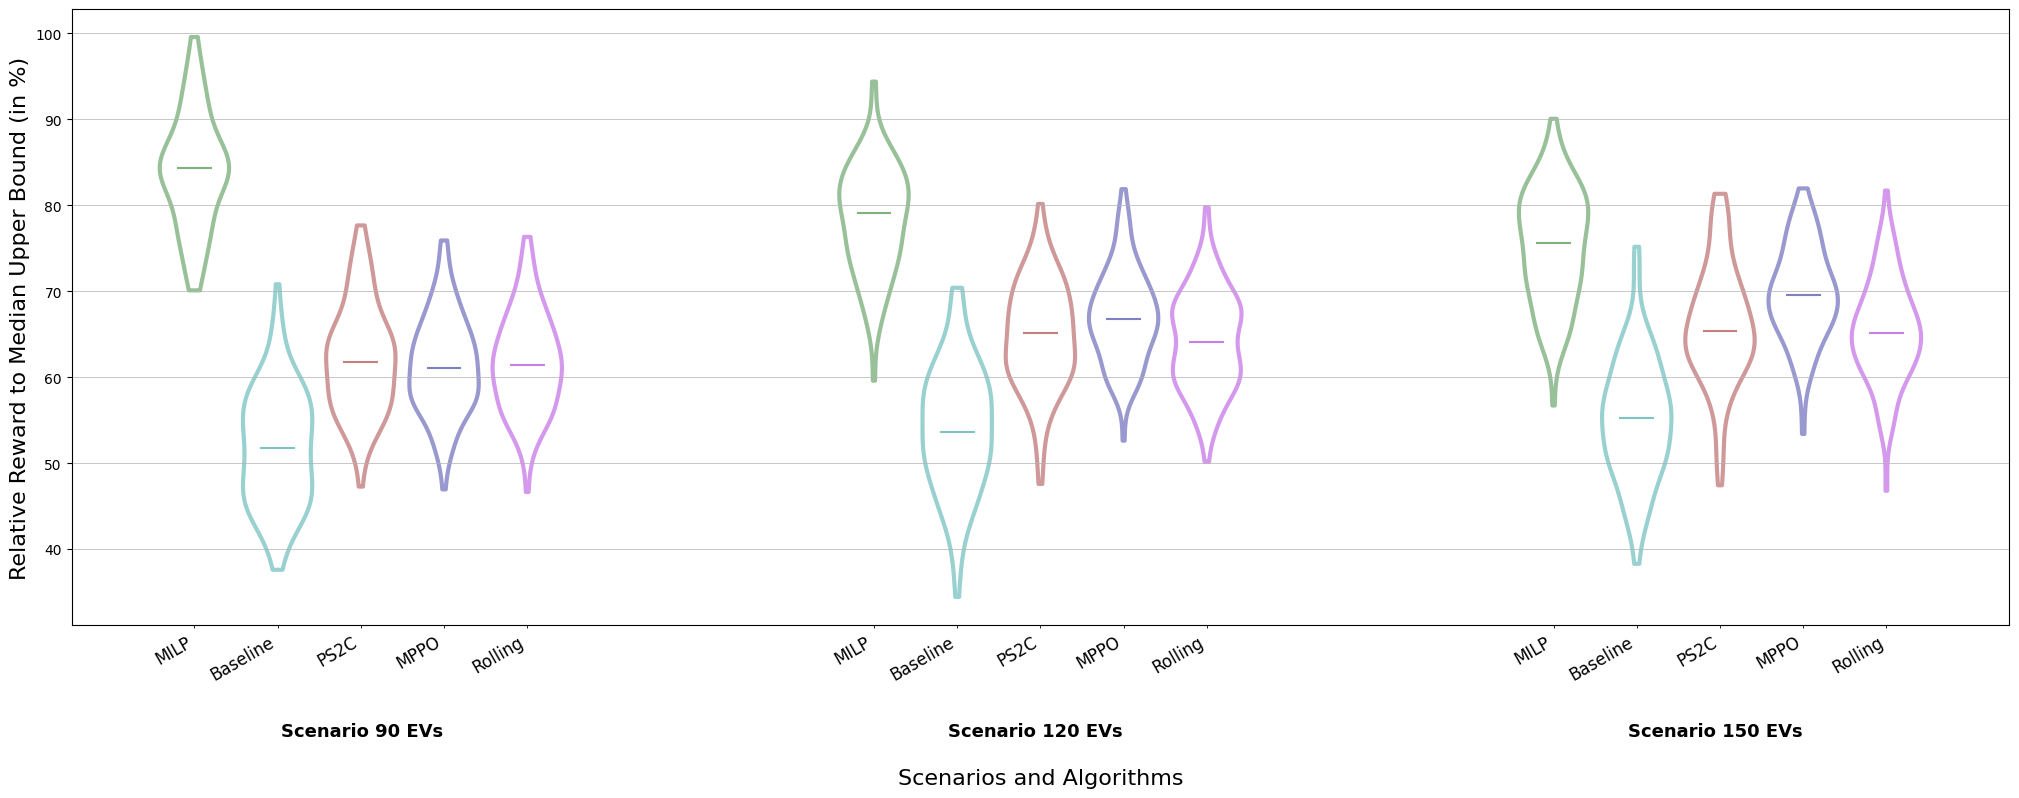

In [17]:
global_cost_distribution_perc_on_lb(df, selected_scenarios=['Scenario 50 EVs', 'Scenario 60 EVs', 'Scenario 70 EVs'],
                                    bar_width=.6, space_between_groups=-.5, figsize=(25, 8))

global_cost_distribution_perc_on_lb(df, selected_scenarios=['Scenario 90 EVs', 'Scenario 120 EVs', 'Scenario 150 EVs'],
                                    bar_width=.6, space_between_groups=-.5, figsize=(25, 8))

{0: 5252.487380632231, 1: 5217.6933520442935, 2: 4824.647080314107, 3: 4833.83998615408, 4: 5566.863711633337, 5: 4450.071418960444, 6: 4321.603565857033, 7: 4993.247392555438, 8: 5643.568965275599, 9: 5596.324787979691, 10: 5365.891893194132, 11: 4930.630269556161, 12: 4947.796859297591, 13: 5566.549062946179, 14: 5480.761963999078, 15: 5510.063702535732, 16: 4732.125269550165, 17: 5365.312125666512, 18: 5581.44073238484, 19: 4663.348828554165, 20: 4914.858374203898, 21: 4852.02458843966, 22: 5465.402488157534, 23: 5225.17799631715, 24: 4541.734534174161, 25: 5314.979120467546, 26: 5537.19882020777, 27: 4949.87441301407, 28: 4655.34724820032, 29: 6409.611186588639, 30: 5192.848809238358, 31: 5335.355071543415, 32: 5451.989304674089, 33: 4563.778932866113, 34: 4444.167707006204, 35: 4955.86670087006, 36: 5658.414713553039, 37: 5847.007044494693, 38: 5134.07271642855, 39: 5334.474355162938, 40: 4961.70856437425, 41: 4586.546949380402, 42: 4796.95644740049, 43: 5073.0468104130905, 44: 53

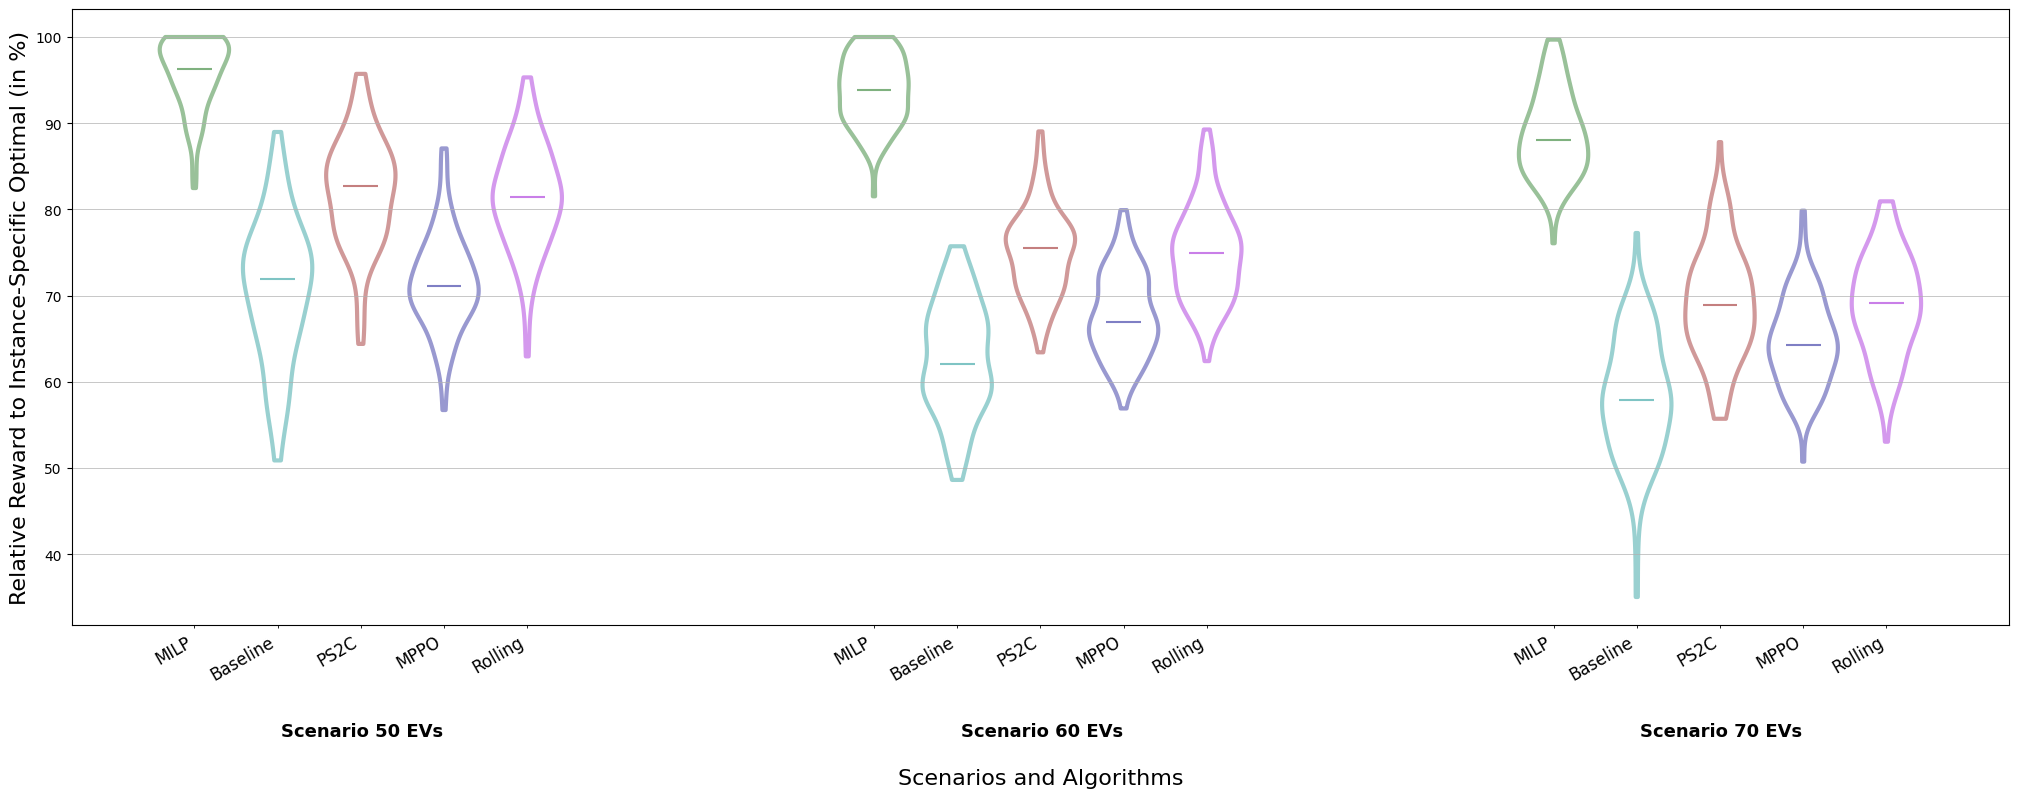

{0: 7202.794637293205, 1: 9436.991455070101, 2: 6369.420343467731, 3: 6550.2477919563025, 4: 7119.246805406986, 5: 6595.475911596121, 6: 6413.412570286518, 7: 8007.566724604724, 8: 6530.024168561633, 9: 6894.459528834987, 10: 7402.481091166587, 11: 7310.403565912707, 12: 7477.098764802182, 13: 7701.4003607951145, 14: 7864.002907942356, 15: 8257.335988642459, 16: 7460.954934803039, 17: 7605.866658743469, 18: 7742.8267076440625, 19: 7763.354178467782, 20: 6533.897648545797, 21: 7733.855398393083, 22: 7960.268677120614, 23: 9431.692979250503, 24: 7764.472249550864, 25: 7636.4165269743235, 26: 7796.806708771301, 27: 7153.3239154899775, 28: 7763.024511924579, 29: 8366.492408394435, 30: 7430.8855437776, 31: 7858.446326221373, 32: 7887.9129378654225, 33: 8246.985711932977, 34: 7216.051502209866, 35: 8491.833089360427, 36: 9277.370683893594, 37: 7901.45724898146, 38: 8956.886676602167, 39: 7356.053130973468, 40: 6856.255016386914, 41: 7449.544793447706, 42: 7982.01782301489, 43: 7170.832025029

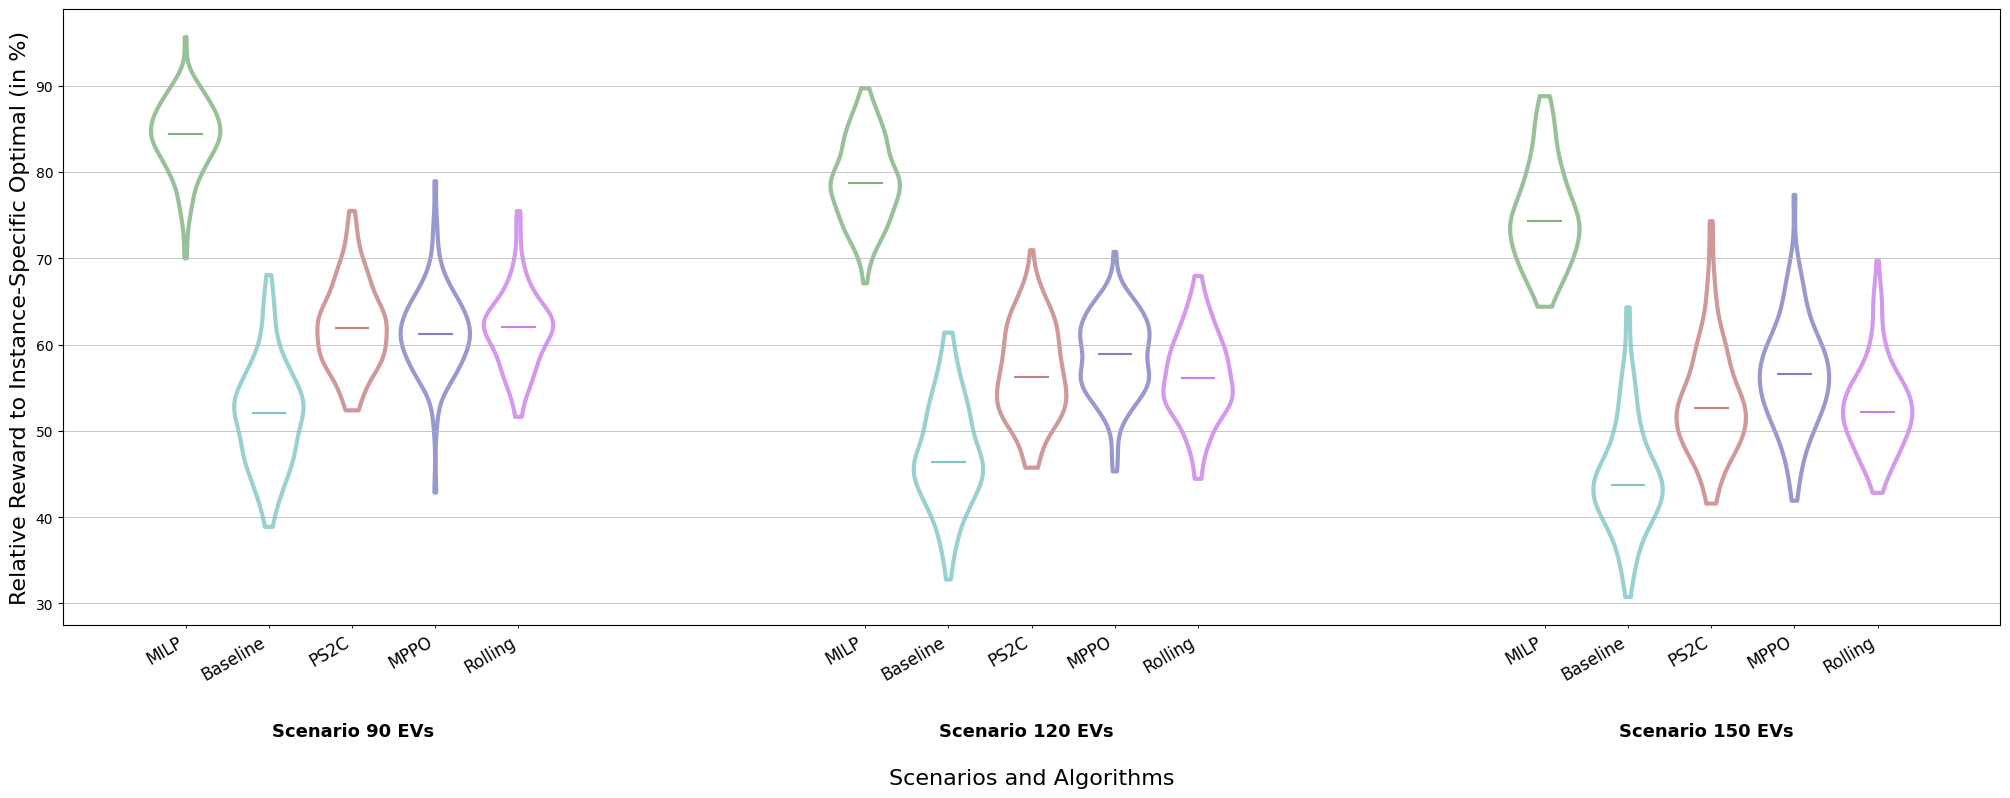

In [20]:
global_cost_distribution_perc_on_lb_corrected(df, selected_scenarios=['Scenario 50 EVs', 'Scenario 60 EVs', 'Scenario 70 EVs'],
                                    bar_width=.6, space_between_groups=-.5, figsize=(25, 8))

global_cost_distribution_perc_on_lb_corrected(df, selected_scenarios=['Scenario 90 EVs', 'Scenario 120 EVs', 'Scenario 150 EVs'],
                                    bar_width=.6, space_between_groups=-.5, figsize=(25, 8))

In [11]:
class ComputeRatioPerc:
    def __init__(self, column_name_1, column_name_2):
        self.column_name_1 = column_name_1
        self.column_name_2 = column_name_2
    
    def __call__(self, row):
        m1, s1 = map(float, row[self.column_name_1].split('±'))
        m2, s2 = map(float, row[self.column_name_2].split('±'))
        rm = m1/m2
        rs = (rm * np.sqrt((s1 / m1) ** 2 + (s2 / m2) ** 2))
        return f"{rm*100:.2f}±{rs*100:.2f}%"


selected_algorithms = ['Baseline', 'MILP', 'MPPO', 'PS2C', 'Rolling']
filtered_df = df[df['Algorithm'].isin(selected_algorithms)].copy()
cumulative_grid_limit = 75 * 24
filtered_df['Grid Limit Used'] = filtered_df['Grid used'].apply(lambda e: f"{float(e.split('±')[0])/cumulative_grid_limit*100:.2f}±{float(e.split('±')[1])/cumulative_grid_limit*100:.2f}%")
filtered_df['PV Share'] = filtered_df.apply(ComputeRatioPerc('PV used', 'Total Energy'), axis=1)
filtered_df['PV Prod. Used'] = filtered_df.apply(ComputeRatioPerc('PV used', 'Total PV'), axis=1)

from IPython.display import HTML
HTML(filtered_df.sort_values(by=['Scenario', 'Algorithm']).reset_index()[['Scenario', 'Algorithm', 'Price', 'Grid Limit Used', 'PV Share', 'PV Prod. Used']].to_html(index=False))

Scenario,Algorithm,Price,Grid Limit Used,PV Share,PV Prod. Used
Scenario 120 EVs,Baseline,82.71±16.28,55.02±6.26%,22.19±10.03%,98.32±62.25%
Scenario 120 EVs,MILP,61.61±17.38,42.82±8.31%,26.94±12.19%,98.94±62.67%
Scenario 120 EVs,MPPO,77.80±15.47,52.53±6.68%,23.03±10.32%,98.45±62.21%
Scenario 120 EVs,PS2C,70.37±15.69,48.06±6.73%,24.43±10.93%,97.32±61.50%
Scenario 120 EVs,Rolling,51.64±13.97,34.99±6.70%,29.88±13.26%,93.39±58.60%
Scenario 150 EVs,Baseline,85.62±14.64,56.41±6.25%,21.94±9.59%,99.38±60.73%
Scenario 150 EVs,MILP,61.56±17.43,42.61±8.79%,27.16±11.93%,99.62±60.89%
Scenario 150 EVs,MPPO,81.87±14.77,54.89±6.16%,22.37±9.72%,99.16±60.51%
Scenario 150 EVs,PS2C,72.40±14.93,49.26±6.66%,24.03±10.37%,97.72±59.49%
Scenario 150 EVs,Rolling,54.54±14.47,36.54±7.09%,29.39±12.59%,95.37±57.62%


In [12]:
selected_algorithms = ['Baseline', 'MILP', 'MPPO', 'PS2C', 'Rolling']
filtered_df = df[df['Algorithm'].isin(selected_algorithms)]

from IPython.display import HTML
HTML(filtered_df.sort_values(by=['Scenario', 'Algorithm']).reset_index()[['Scenario', 'Algorithm', 'Charging satisf. <80%', 'Charging satisf. >=80%', 'Waiting Time', 'Final SoC']].to_html(index=False))

Scenario,Algorithm,Charging satisf. <80%,Charging satisf. >=80%,Waiting Time,Final SoC
Scenario 120 EVs,Baseline,25.99±4.21%,29.41±4.43%,33.96±3.59,79.00±2.81%
Scenario 120 EVs,MILP,9.87±3.27%,51.60±4.39%,29.02±2.74,73.54±2.36%
Scenario 120 EVs,MPPO,8.12±2.75%,38.51±3.24%,12.06±1.83,89.58±1.81%
Scenario 120 EVs,PS2C,19.23±3.23%,36.16±3.68%,33.97±3.59,75.13±1.74%
Scenario 120 EVs,Rolling,18.21±3.01%,35.75±3.37%,38.78±3.97,67.34±2.42%
Scenario 150 EVs,Baseline,21.32±3.04%,24.01±3.37%,35.75±2.75,78.64±2.08%
Scenario 150 EVs,MILP,9.56±2.93%,42.37±4.00%,28.47±1.87,72.86±2.20%
Scenario 150 EVs,MPPO,7.96±2.13%,31.94±2.65%,13.57±1.78,88.46±1.64%
Scenario 150 EVs,PS2C,15.85±2.35%,29.48±3.22%,35.73±2.74,74.72±1.10%
Scenario 150 EVs,Rolling,14.39±2.24%,29.16±2.79%,41.50±2.80,67.48±1.96%


# Appendix: PPO/MPPO/MPPO + Post Masking Comparisons

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

STEP_PLOT_LIMIT = 9_000_000

def smooth_values(data, column_name, window_size):
    return data[column_name].rolling(window=window_size, center=True, min_periods=1).mean()

def correction_best_values(values):
    best_val = values[0]
    for i, val in enumerate(values):
        if val > best_val:
            best_val = val
        elif val < best_val:
            values[i] = best_val
    return values

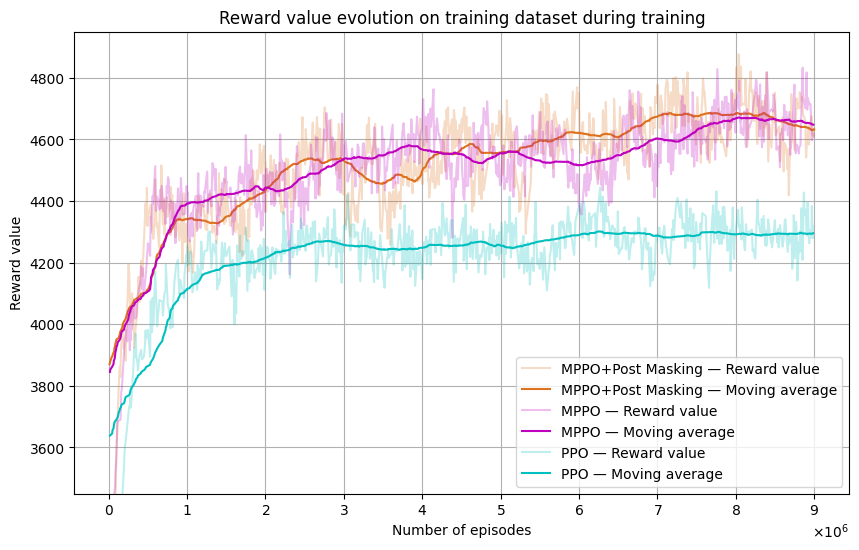

In [2]:
res_mppo = pd.read_csv('./reinforcement_learning/Adapted_MPPO_training.csv')
res_orig_mppo = pd.read_csv('./reinforcement_learning/Original_MPPO_training.csv')
res_ppo = pd.read_csv('./reinforcement_learning/PPO_training.csv')

res_mppo = res_mppo[res_mppo['Step'] <= STEP_PLOT_LIMIT]
res_orig_mppo = res_orig_mppo[res_orig_mppo['Step'] <= STEP_PLOT_LIMIT]
res_ppo = res_ppo[res_ppo['Step'] <= STEP_PLOT_LIMIT]

res_ppo['Smoothed Value'] = smooth_values(res_ppo, 'Value', 100)
res_mppo['Smoothed Value'] = smooth_values(res_mppo, 'Value', 100)
res_orig_mppo['Smoothed Value'] = smooth_values(res_orig_mppo, 'Value', 100)

plt.figure(figsize=(10, 6))
plt.plot(res_mppo['Step'], res_mppo['Value'], marker=None, linestyle='-', alpha=.25, color='#de721e', label="MPPO+Post Masking — Reward value")
plt.plot(res_mppo['Step'], res_mppo['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='#de721e', label="MPPO+Post Masking — Moving average")
plt.plot(res_orig_mppo['Step'], res_orig_mppo['Value'], marker=None, linestyle='-', alpha=.25, color='m', label="MPPO — Reward value")
plt.plot(res_orig_mppo['Step'], res_orig_mppo['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='m', label="MPPO — Moving average")
plt.plot(res_ppo['Step'], res_ppo['Value'], marker=None, linestyle='-', alpha=.25, color='c', label="PPO — Reward value")
plt.plot(res_ppo['Step'], res_ppo['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='c', label="PPO — Moving average")
plt.title('Reward value evolution on training dataset during training')
plt.xlabel('Number of episodes')
plt.ylabel('Reward value')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ticks = list(range(0, STEP_PLOT_LIMIT+1_000_000, 1_000_000))
plt.xticks(ticks, rotation='horizontal')
plt.ylim(3450, 4950)
plt.grid(True)
plt.legend()

plt.savefig('rl_training.png', dpi=600)
plt.show()

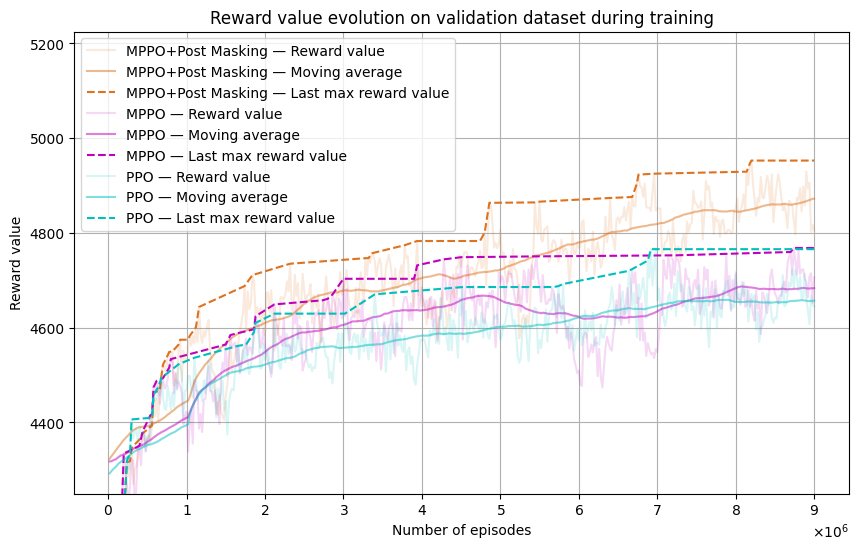

In [3]:
res_mppo_best = pd.read_csv('./reinforcement_learning/Adapted_MPPO_evaluation_best.csv')
res_orig_mppo_best = pd.read_csv('./reinforcement_learning/Original_MPPO_evaluation_best.csv')
res_ppo_best = pd.read_csv('./reinforcement_learning/PPO_evaluation_best.csv')
res_mppo = pd.read_csv('./reinforcement_learning/Adapted_MPPO_evaluation.csv')
res_orig_mppo = pd.read_csv('./reinforcement_learning/Original_MPPO_evaluation.csv')
res_ppo = pd.read_csv('./reinforcement_learning/PPO_evaluation.csv')

res_mppo_best = res_mppo_best[res_mppo_best['Step'] <= STEP_PLOT_LIMIT]
res_orig_mppo_best = res_orig_mppo_best[res_orig_mppo_best['Step'] <= STEP_PLOT_LIMIT]
res_ppo_best = res_ppo_best[res_ppo_best['Step'] <= STEP_PLOT_LIMIT]
res_mppo = res_mppo[res_mppo['Step'] <= STEP_PLOT_LIMIT]
res_orig_mppo = res_orig_mppo[res_orig_mppo['Step'] <= STEP_PLOT_LIMIT]
res_ppo = res_ppo[res_ppo['Step'] <= STEP_PLOT_LIMIT]

res_ppo['Smoothed Value'] = smooth_values(res_ppo, 'Value', 100)
res_mppo['Smoothed Value'] = smooth_values(res_mppo, 'Value', 100)
res_orig_mppo['Smoothed Value'] = smooth_values(res_orig_mppo, 'Value', 100)
res_ppo_best['Value'] = correction_best_values(res_ppo_best['Value'].copy())
res_mppo_best['Value'] = correction_best_values(res_mppo_best['Value'].copy())
res_orig_mppo_best['Value'] = correction_best_values(res_orig_mppo_best['Value'].copy())
res_ppo_best.loc[max(res_ppo_best.index)+1] = [.0, res_ppo['Step'].to_numpy()[-1], res_ppo_best['Value'].to_numpy()[-1]]
res_mppo_best.loc[max(res_mppo_best.index)+1] = [.0, res_mppo['Step'].to_numpy()[-1], res_mppo_best['Value'].to_numpy()[-1]]
res_orig_mppo_best.loc[max(res_orig_mppo_best.index)+1] = [.0, res_orig_mppo['Step'].to_numpy()[-1], res_orig_mppo_best['Value'].to_numpy()[-1]]

plt.figure(figsize=(10, 6))
plt.plot(res_mppo['Step'], res_mppo['Value'], marker=None, linestyle='-', alpha=.15, color='#de721e', label="MPPO+Post Masking — Reward value")
plt.plot(res_mppo['Step'], res_mppo['Smoothed Value'], marker=None, linestyle='-', alpha=.5, color='#de721e', label="MPPO+Post Masking — Moving average")
plt.plot(res_mppo_best['Step'], res_mppo_best['Value'], marker=None, linestyle='--', alpha=1., color='#de721e', label="MPPO+Post Masking — Last max reward value")
plt.plot(res_orig_mppo['Step'], res_orig_mppo['Value'], marker=None, linestyle='-', alpha=.15, color='m', label="MPPO — Reward value")
plt.plot(res_orig_mppo['Step'], res_orig_mppo['Smoothed Value'], marker=None, linestyle='-', alpha=.5, color='m', label="MPPO — Moving average")
plt.plot(res_orig_mppo_best['Step'], res_orig_mppo_best['Value'], marker=None, linestyle='--', alpha=1., color='m', label="MPPO — Last max reward value")
plt.plot(res_ppo['Step'], res_ppo['Value'], marker=None, linestyle='-', alpha=.15, color='c', label="PPO — Reward value")
plt.plot(res_ppo['Step'], res_ppo['Smoothed Value'], marker=None, linestyle='-', alpha=.5, color='c', label="PPO — Moving average")
plt.plot(res_ppo_best['Step'], res_ppo_best['Value'], marker=None, linestyle='--', alpha=1., color='c', label="PPO — Last max reward value")
plt.title('Reward value evolution on validation dataset during training')
plt.xlabel('Number of episodes')
plt.ylabel('Reward value')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ticks = list(range(0, STEP_PLOT_LIMIT+1_000_000, 1_000_000))
plt.xticks(ticks, rotation='horizontal')
plt.ylim(4250, 5225)
plt.grid(True)
plt.legend()

plt.savefig('rl_evaluation.png', dpi=600)
plt.show()

# Appendix: MPPO + Post Masking with/out price prediction and without any prediction comparisons

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

STEP_PLOT_LIMIT = 9_000_000

def smooth_values(data, column_name, window_size):
    return data[column_name].rolling(window=window_size, center=True, min_periods=1).mean()

def correction_best_values(values):
    best_val = values[0]
    for i, val in enumerate(values):
        if val > best_val:
            best_val = val
        elif val < best_val:
            values[i] = best_val
    return values

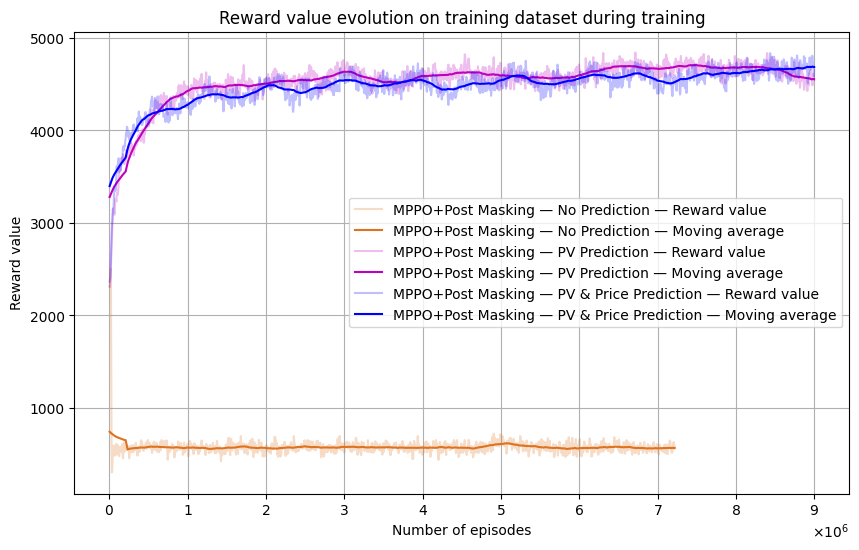

In [5]:
res_mppo_no_pred = pd.read_csv('./reinforcement_learning/Adapted_MPPO_without_any_prediction_training.csv')
res_mppo_no_price = pd.read_csv('./reinforcement_learning/Adapted_MPPO_without_price_prediction_training.csv')
res_mppo_price = pd.read_csv('./reinforcement_learning/Adapted_MPPO_with_price_prediction_training.csv')
res_orig_mppo = pd.read_csv('./reinforcement_learning/Original_MPPO_with_price_prediction_training.csv')

res_mppo_no_pred = res_mppo_no_pred[res_mppo_no_pred['Step'] <= STEP_PLOT_LIMIT]
res_mppo_no_price = res_mppo_no_price[res_mppo_no_price['Step'] <= STEP_PLOT_LIMIT]
res_mppo_price = res_mppo_price[res_mppo_price['Step'] <= STEP_PLOT_LIMIT]
res_orig_mppo = res_orig_mppo[res_orig_mppo['Step'] <= STEP_PLOT_LIMIT]

res_mppo_no_pred['Smoothed Value'] = smooth_values(res_mppo_no_pred, 'Value', 100)
res_mppo_no_price['Smoothed Value'] = smooth_values(res_mppo_no_price, 'Value', 100)
res_mppo_price['Smoothed Value'] = smooth_values(res_mppo_price, 'Value', 100)
res_orig_mppo['Smoothed Value'] = smooth_values(res_orig_mppo, 'Value', 100)

plt.figure(figsize=(10, 6))
plt.plot(res_mppo_no_pred['Step'], res_mppo_no_pred['Value'], marker=None, linestyle='-', alpha=.25, color='#de721e', label="MPPO+Post Masking — No Prediction — Reward value")
plt.plot(res_mppo_no_pred['Step'], res_mppo_no_pred['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='#de721e', label="MPPO+Post Masking — No Prediction — Moving average")
plt.plot(res_mppo_no_price['Step'], res_mppo_no_price['Value'], marker=None, linestyle='-', alpha=.25, color='m', label="MPPO+Post Masking — PV Prediction — Reward value")
plt.plot(res_mppo_no_price['Step'], res_mppo_no_price['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='m', label="MPPO+Post Masking — PV Prediction — Moving average")
plt.plot(res_mppo_price['Step'], res_mppo_price['Value'], marker=None, linestyle='-', alpha=.25, color='b', label="MPPO+Post Masking — PV & Price Prediction — Reward value")
plt.plot(res_mppo_price['Step'], res_mppo_price['Smoothed Value'], marker=None, linestyle='-', alpha=1., color='b', label="MPPO+Post Masking — PV & Price Prediction — Moving average")
plt.title('Reward value evolution on training dataset during training')
plt.xlabel('Number of episodes')
plt.ylabel('Reward value')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ticks = list(range(0, STEP_PLOT_LIMIT+1_000_000, 1_000_000))
plt.xticks(ticks, rotation='horizontal')
plt.grid(True)
plt.legend()

plt.savefig('rl_training_price.png', dpi=600)
plt.show()

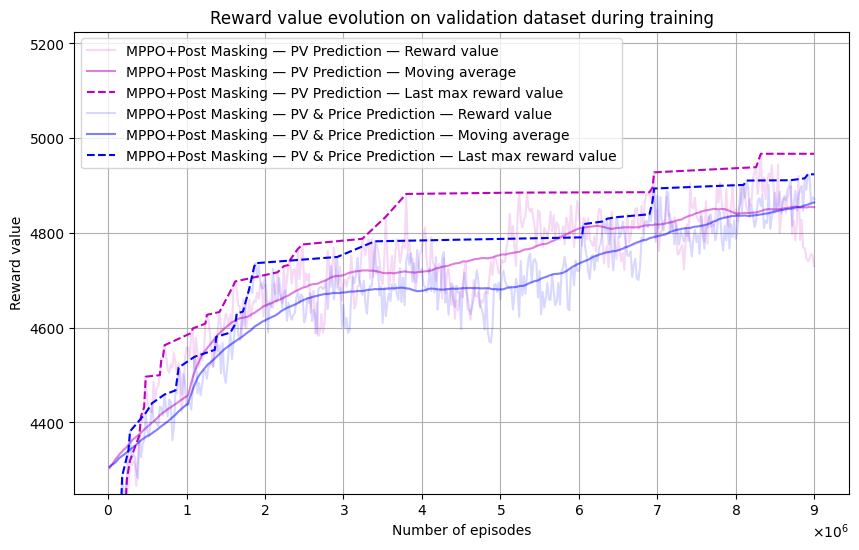

In [4]:
res_mppo_no_price_best = pd.read_csv('./reinforcement_learning/Adapted_MPPO_without_price_prediction_evaluation_best.csv')
res_mppo_price_best = pd.read_csv('./reinforcement_learning/Adapted_MPPO_with_price_prediction_evaluation_best.csv')
res_mppo_no_price = pd.read_csv('./reinforcement_learning/Adapted_MPPO_without_price_prediction_evaluation.csv')
res_mppo_price = pd.read_csv('./reinforcement_learning/Adapted_MPPO_with_price_prediction_evaluation.csv')

res_mppo_no_price_best = res_mppo_no_price_best[res_mppo_no_price_best['Step'] <= STEP_PLOT_LIMIT]
res_mppo_price_best = res_mppo_price_best[res_mppo_price_best['Step'] <= STEP_PLOT_LIMIT]
res_mppo_no_price = res_mppo_no_price[res_mppo_no_price['Step'] <= STEP_PLOT_LIMIT]
res_mppo_price = res_mppo_price[res_mppo_price['Step'] <= STEP_PLOT_LIMIT]

res_mppo_no_price['Smoothed Value'] = smooth_values(res_mppo_no_price, 'Value', 100)
res_mppo_price['Smoothed Value'] = smooth_values(res_mppo_price, 'Value', 100)
res_mppo_no_price_best['Value'] = correction_best_values(res_mppo_no_price_best['Value'].copy())
res_mppo_price_best['Value'] = correction_best_values(res_mppo_price_best['Value'].copy())
res_mppo_no_price_best.loc[max(res_mppo_no_price_best.index)+1] = [.0, res_mppo_no_price['Step'].to_numpy()[-1], res_mppo_no_price_best['Value'].to_numpy()[-1]]
res_mppo_price_best.loc[max(res_mppo_price_best.index)+1] = [.0, res_mppo_price['Step'].to_numpy()[-1], res_mppo_price_best['Value'].to_numpy()[-1]]

plt.figure(figsize=(10, 6))
plt.plot(res_mppo_no_price['Step'], res_mppo_no_price['Value'], marker=None, linestyle='-', alpha=.15, color='m', label="MPPO+Post Masking — PV Prediction — Reward value")
plt.plot(res_mppo_no_price['Step'], res_mppo_no_price['Smoothed Value'], marker=None, linestyle='-', alpha=.5, color='m', label="MPPO+Post Masking — PV Prediction — Moving average")
plt.plot(res_mppo_no_price_best['Step'], res_mppo_no_price_best['Value'], marker=None, linestyle='--', alpha=1., color='m', label="MPPO+Post Masking — PV Prediction — Last max reward value")
plt.plot(res_mppo_price['Step'], res_mppo_price['Value'], marker=None, linestyle='-', alpha=.15, color='b', label="MPPO+Post Masking — PV & Price Prediction — Reward value")
plt.plot(res_mppo_price['Step'], res_mppo_price['Smoothed Value'], marker=None, linestyle='-', alpha=.5, color='b', label="MPPO+Post Masking — PV & Price Prediction — Moving average")
plt.plot(res_mppo_price_best['Step'], res_mppo_price_best['Value'], marker=None, linestyle='--', alpha=1., color='b', label="MPPO+Post Masking — PV & Price Prediction — Last max reward value")
plt.title('Reward value evolution on validation dataset during training')
plt.xlabel('Number of episodes')
plt.ylabel('Reward value')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ticks = list(range(0, STEP_PLOT_LIMIT+1_000_000, 1_000_000))
plt.xticks(ticks, rotation='horizontal')
plt.ylim(4250, 5225)
plt.grid(True)
plt.legend()

plt.savefig('rl_evaluation_price.png', dpi=600)
plt.show()